# 03 — Model Training

Trains the required Random Forest classifier with a stratified train/test split, saves the model and label encoder, and writes evaluation results.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'data').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.preprocessing import prepare_model_data
from src.model import train_random_forest, save_artifacts

raw = pd.read_csv(ROOT / 'data' / 'cleaned_data.csv')
X, y = prepare_model_data(raw)
print('Features:', list(X.columns))
print('Classes:', sorted(y.unique()))

Features: ['Age', 'BMI', 'Blood Pressure', 'Glucose Level', 'Cholesterol', 'Gender', 'Smoking Status', 'Physical Activity', 'Medical History']
Classes: ['High', 'Low', 'Medium']


In [6]:
pipeline, label_encoder, metrics, cm_df, predictions = train_random_forest(X, y, random_state=42)
print(f"Accuracy: {metrics['accuracy']:.3f}")
print(f"Precision: {metrics['precision_weighted']:.3f}")
print(f"Recall: {metrics['recall_weighted']:.3f}")
print(f"F1-score: {metrics['f1_weighted']:.3f}")


Accuracy: 0.700
Precision: 0.701
Recall: 0.700
F1-score: 0.700


In [7]:
(ROOT/'models').mkdir(exist_ok=True)
(ROOT/'outputs'/'model_results').mkdir(parents=True, exist_ok=True)
save_artifacts(
    pipeline,
    label_encoder,
    ROOT/'models'/'random_forest.pkl',
    ROOT/'models'/'label_encoder.pkl'
)
(ROOT/'outputs'/'model_results'/'metrics.json').write_text(json.dumps(metrics, indent=2, default=float))
cm_df.to_csv(ROOT/'outputs'/'model_results'/'confusion_matrix.csv')
predictions.to_csv(ROOT/'outputs'/'model_results'/'test_predictions.csv', index=False)
print('Model artifacts and evaluation files saved.')

Model artifacts and evaluation files saved.


/Users/gauri/Downloads/Health-Risk-Dashboard/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


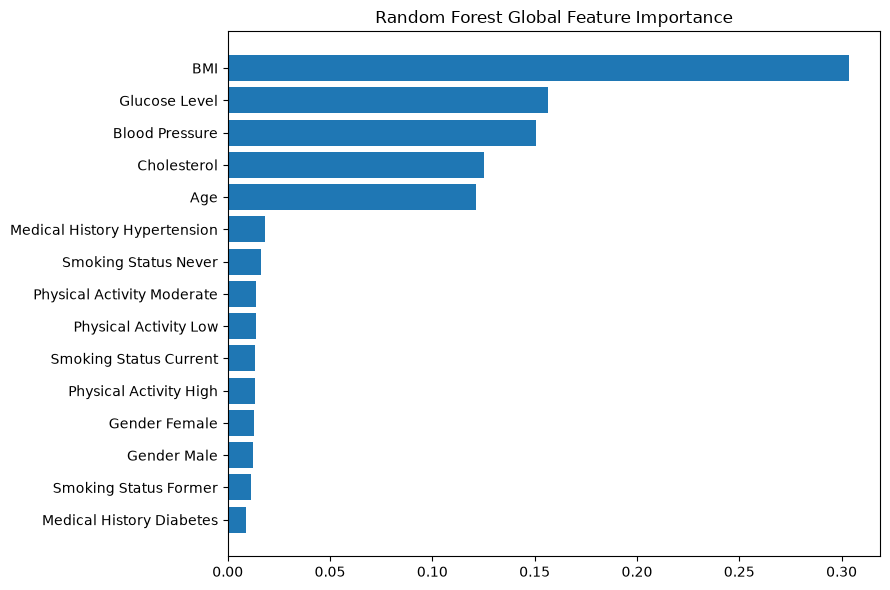

In [8]:
import matplotlib.pyplot as plt
from src.explainability import global_feature_importance, human_feature_name

importance = global_feature_importance(pipeline).head(15).copy()
importance['Readable Feature'] = importance['Feature'].map(human_feature_name)
importance = importance.sort_values('Importance')

plt.figure(figsize=(9,6))
plt.barh(importance['Readable Feature'], importance['Importance'])
plt.title('Random Forest Global Feature Importance')
plt.tight_layout()
plt.savefig(ROOT/'outputs'/'graphs'/'feature_importance.png', dpi=160)
plt.show()

## Result

The saved artifacts are loaded by `app.py` so the dashboard does not retrain the model on every interaction.